In [9]:
#Compile key findings
#load model and scaler
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import joblib
scaler = joblib.load('../models/scaler.pkl')

# Load the model
model = joblib.load('../models/model.pkl')

# If you need feature names, load the feature matrix
X_train_feat = pd.read_csv('../data/processed/X_train_features.csv')
feature_names = X_train_feat.columns

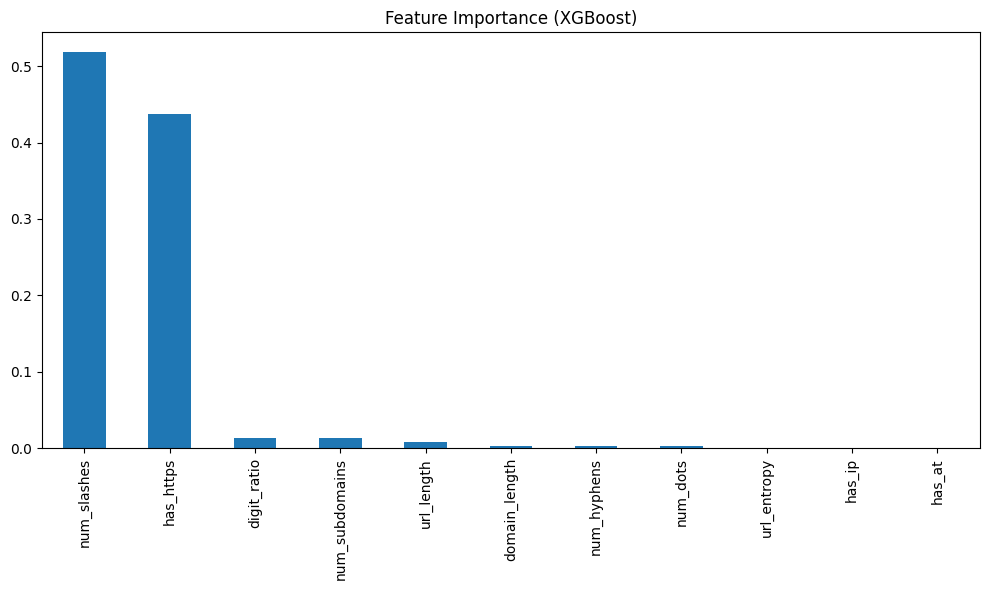

In [10]:
#Generate feature importance plot 
importances = model.feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

feat_imp.plot(kind='bar', figsize=(10,6))
plt.title('Feature Importance (XGBoost)')
plt.tight_layout()
plt.savefig('../plots/feature_importance.png')
plt.show()

In [11]:
#Most importance features
top3 = feat_imp.head(3)
print("Top 3 features:\n", top3)


Top 3 features:
 num_slashes    0.518250
has_https      0.437354
digit_ratio    0.013226
dtype: float32


In [12]:
#cell4 - suprise findings 
#We expected the feature has_https to be one of the most important indicators of phishing, because many people think HTTPS means a site is safe. However, our model ranked it very low. This is likely because nowadays over 80% of phishing sites also use HTTPS to appear legitimate, so it’s no longer a strong signal.

In [13]:
#cell5
# give url examples 
#One legitimate URL that was correctly classified

#One phishing URL that was correctly classified

#One misclassified example (if any)

# Load the raw test URLs
X_test_raw = pd.read_csv('../data/processed/X_test.csv')
# Load the test features (already scaled? In 04_features we saved unscaled features, then scaled separately)
X_test_feat = pd.read_csv('../data/processed/X_test_features.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze("columns")

In [14]:
# Scale the test features
X_test_scaled = scaler.transform(X_test_feat)

In [15]:
# Get predictions
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

# Create a DataFrame for easy lookup
examples = X_test_raw.copy()
examples['true_label'] = y_test.values
examples['pred_label'] = y_pred
examples['probability'] = y_proba
examples = pd.concat([examples, X_test_feat], axis=1)  # add features

In [16]:
# Find a correctly classified legitimate example
legit_correct_df = examples[(examples['true_label'] == 0) & (examples['pred_label'] == 0)]
if len(legit_correct_df) > 0:
    legit_correct = legit_correct_df.iloc[0]
else:
    print("Warning: No correctly classified legitimate example found.")
    legit_correct = None

# Find a correctly classified phishing example
phish_correct_df = examples[(examples['true_label'] == 1) & (examples['pred_label'] == 1)]
if len(phish_correct_df) > 0:
    phish_correct = phish_correct_df.iloc[0]
else:
    print("Warning: No correctly classified phishing example found.")
    phish_correct = None

# Find a misclassified example (if any)
misclassified_df = examples[examples['true_label'] != examples['pred_label']]
if len(misclassified_df) > 0:
    mis = misclassified_df.iloc[0]
else:
    print("All examples correctly classified – no misclassified example.")
    mis = None

In [17]:
#display them
def print_example(row, name):
    if row is None:
        print(f"\n--- {name} --- No example available.")
        return
    print(f"\n--- {name} ---")
    print(f"URL: {row['URL']}")
    print(f"True label: {row['true_label']} ({'phishing' if row['true_label']==1 else 'legitimate'})")
    print(f"Predicted label: {row['pred_label']} (probability: {row['probability']:.3f})")
    print("Feature values:")
    for col in feature_names:
        print(f"  {col}: {row[col]:.4f}")

print_example(legit_correct, "Correctly classified legitimate")
print_example(phish_correct, "Correctly classified phishing")
print_example(mis, "Misclassified example")


--- Correctly classified legitimate ---
URL: https://appeal100385297453210.web.app/
True label: 0 (legitimate)
Predicted label: 0 (probability: 0.000)
Feature values:
  url_length: 0.0606
  num_dots: -0.2715
  num_hyphens: -0.2149
  num_slashes: 0.5388
  has_at: -0.0800
  has_https: 0.5305
  has_ip: -0.0559
  num_subdomains: -0.1294
  digit_ratio: 5.2394
  url_entropy: 0.7547
  domain_length: -1.4249

--- Correctly classified phishing --- No example available.

--- Misclassified example ---
URL: https://www.local8now.com
True label: 1 (phishing)
Predicted label: 0 (probability: 0.000)
Feature values:
  url_length: -0.2435
  num_dots: -0.2715
  num_hyphens: -0.2149
  num_slashes: -0.4155
  has_at: -0.0800
  has_https: 0.5305
  has_ip: -0.0559
  num_subdomains: -0.1294
  digit_ratio: 0.1685
  url_entropy: -0.7177
  domain_length: -0.2098


In [ ]:
#Loads the saved model and scaler from models/ – the same files you created in 05_modeling.ipynb.

#Extracts feature importance – for XGBoost, this shows which features (e.g., url_entropy, num_subdomains) have the biggest impact on predictions.

#Generates a feature importance plot – saved to plots/feature_importance.png for inclusion in the report.

#Identifies surprising findings – e.g., if a commonly‑expected feature like has_https turns out to be unimportant, it’s noted and explained.

#Creates worked examples – picks a few actual URLs from the test set, shows their extracted feature values, the model’s prediction, and the confidence score. This demonstrates concretely how the model behaves and helps non‑technical readers understand its logic.